In [1]:
import matplotlib

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

import os

import matplotlib.pyplot as plt
import pandas as pd
import ptitprince as pt
import seaborn as sns

In [4]:
plot_info = []
src_data_dir = "../utils/detailed_data_100"

for root, sub_dir, files in os.walk(src_data_dir):
    for file in files:
        if file.endswith(".csv"):
            try:
                src_file = os.path.join(root, file)
                dim = int(file[3])
                obj = int(file[9])
                tree = file[16:].strip(".csv").split("_")[0]
                gen = int(file.strip(".csv")[-2:])
                df = pd.read_csv(src_file, index_col=0).fillna(0)
                df["dimension"] = dim
                df["n_objectives"] = obj
                df["tree"] = tree
                df["gen"] = gen
                plot_info.append(df)
            except Exception as e:
                pass

In [5]:
new_df = pd.concat(plot_info, ignore_index=True)

In [22]:
new_df

,solver,exp_index,root,node_1,node_2,node_3,node_4,dimension,n_objectives,tree,gen
0,IBEA,34543,69,0,0,0,31,2,4,breadth,45
1,IBEA,34544,83,0,3,1,13,2,4,breadth,45
2,IBEA,34545,77,0,0,2,21,2,4,breadth,45
3,IBEA,34546,79,14,7,0,0,2,4,breadth,45
4,IBEA,34547,57,0,0,5,38,2,4,breadth,45
...,...,...,...,...,...,...,...,...,...,...,...
1092723,IBEA,34838,73,1,12,14,0,2,4,breadth,48
1092724,IBEA,34839,82,5,0,12,1,2,4,breadth,48
1092725,IBEA,34840,72,1,16,1,10,2,4,breadth,48
1092726,IBEA,34841,78,0,22,0,0,2,4,breadth,48


/Users/umi/miniconda3/envs/benchmark-visualizer/lib/python3.10/site-packages/ptitprince/PtitPrince.py:154: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for group_name, group_df in self.plot_data.groupby(grouping_vars):
/Users/umi/miniconda3/envs/benchmark-visualizer/lib/python3.10/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


TypeError: seaborn.categorical.pointplot() got multiple values for keyword argument 'linestyles'

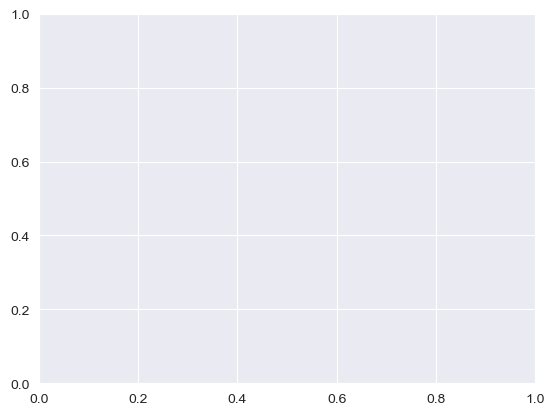

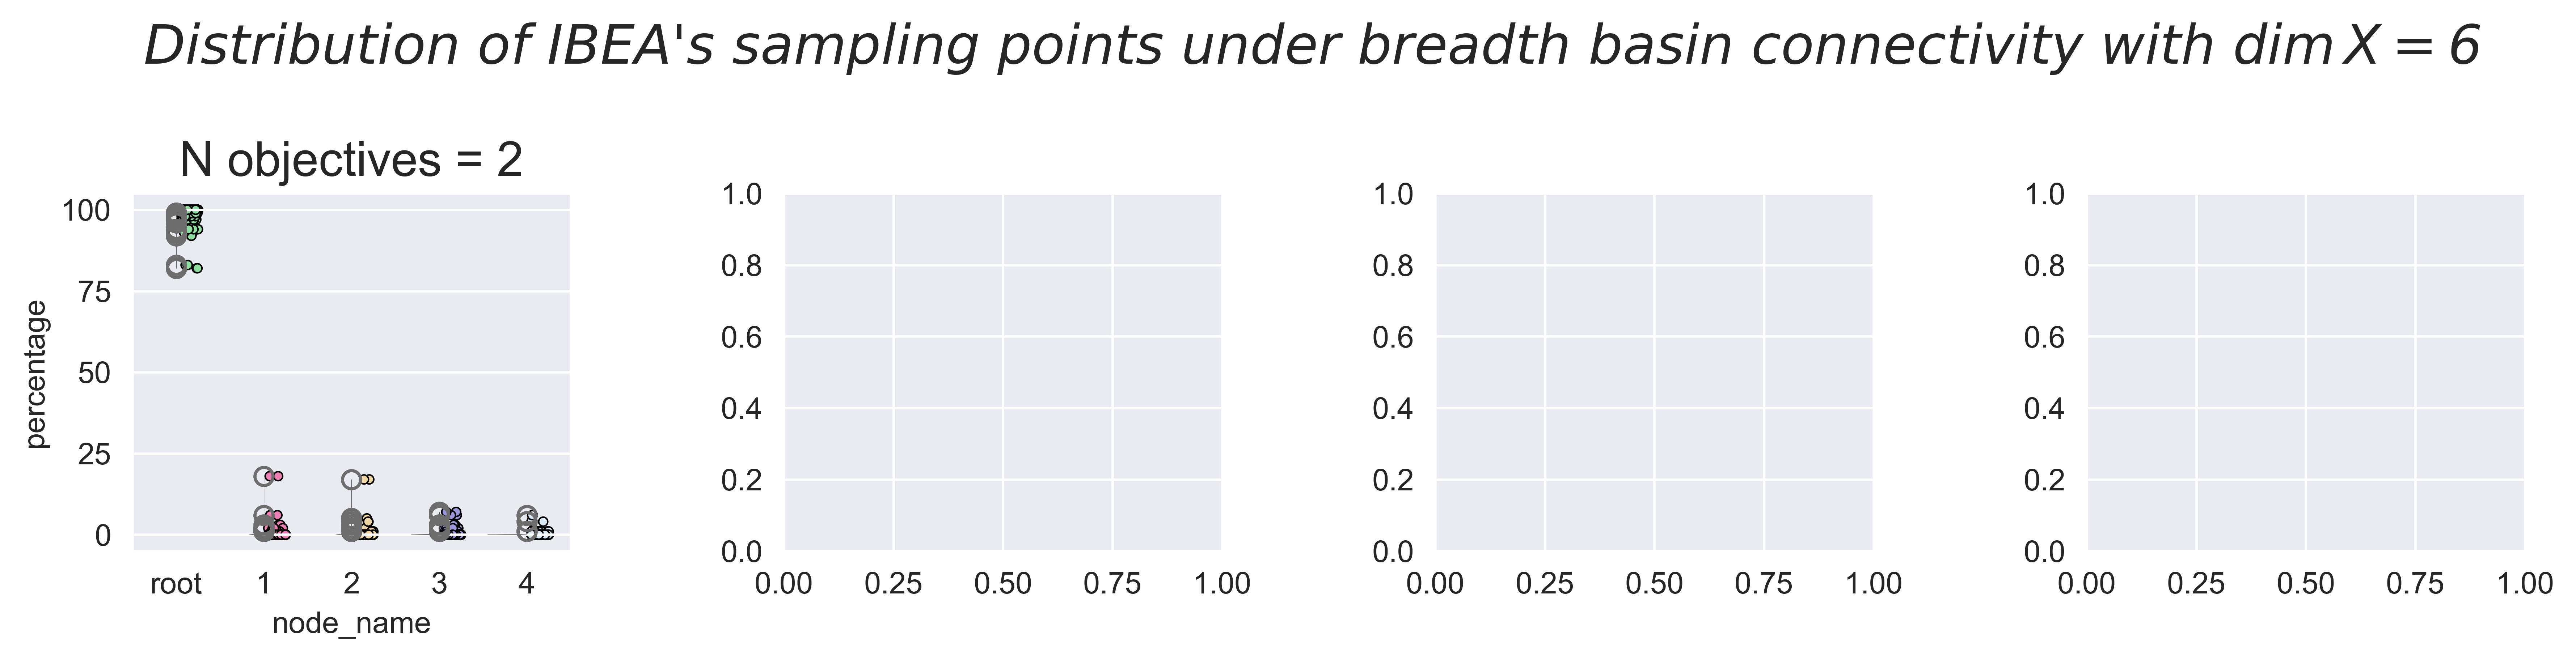

In [7]:
# Mass plot
agg_dim = 6
sss = ["GDE3", "NSGAII", "IBEA", "MOEAD"]
for solver in sss:
    for tree in ["breadth", "depth"]:
        for gen in range(10, 100):
            if not gen in [11, 30]:
                continue
            filtered_dfs = []
            for n_objectives in [2, 3, 4, 5]:
                if n_objectives != 2 and tree == "depth":
                    gen_sel = gen + 10
                else:
                    if n_objectives != 2:
                        gen_sel = gen + 4
                    else:
                        gen_sel = gen
                dimension = agg_dim - n_objectives + 1
                filtered_dfs.append(
                    new_df[
                        (new_df["solver"] == solver)
                        & (new_df["dimension"] == dimension)
                        & (new_df["tree"] == tree)
                        & (new_df["n_objectives"] == n_objectives)
                        & (new_df["gen"] == gen_sel)
                    ]
                )

            filtered_df = pd.concat(filtered_dfs)

            if solver == "MOEAD":
                solver_name = "MOEA/D"
            elif solver == "NSGAII":
                solver_name = "NSGA-II"
            else:
                solver_name = solver

            fig, axs = plt.subplots(1, 4, figsize=(12, 3), dpi=600)
            fig.suptitle(
                f"Distribution of {solver_name}'s sampling points under {tree} basin connectivity with $\operatorname{{dim}}X={agg_dim}$",
                fontsize=18,
            )
            fig.tight_layout(pad=2, w_pad=4, h_pad=5)
            width = 0.6
            colors = ["#8fdea0", "#ec80b4", "#eed5a4", "#9a97dc", "#d7e7f5"]
            palette = sns.color_palette(colors)

            for n_objective, sub_df in filtered_df.groupby("n_objectives"):
                sub_results = []
                for sub_index, row in sub_df.iterrows():
                    sub_results.append({"node_name": "root", "percentage": row["root"]})
                    sub_results.append({"node_name": "1", "percentage": row["node_1"]})
                    sub_results.append({"node_name": "2", "percentage": row["node_2"]})
                    sub_results.append({"node_name": "3", "percentage": row["node_3"]})
                    sub_results.append({"node_name": "4", "percentage": row["node_4"]})
                sub_results = pd.DataFrame(sub_results)
                plt.subplot(1, 4, n_objective - 1)
                plt.title(f"N objectives = {n_objective}", fontsize=16)
                # pt.RainCloud(x="day", y="total_bill", data=tips, orient="v")
                # axs[plot_row,plot_col].set_xlabel("Basin name")
                # axs[plot_row,plot_col].set_ylabel("Percentage of solver instances")
                # axs[plot_row,plot_col].set_ylim([-5, 105])

                plt.ylim([-5, 105])
                # plt.grid(visible=False)
                pt.RainCloud(
                    data=sub_results,
                    x="node_name",
                    y="percentage",
                    orient="v",
                    width_viol=0.9,
                    linewidth=0.1,
                    point_size=3,
                    rain_edgecolor="black",
                    rain_linewidth=0.5,
                    rain_alpha=1,
                    move=0.15,
                    width_box=0,
                    box_linewidth=0,
                    offset=-0.0,
                    pointplot=True,
                    point_linestyles="",
                    point_scale=0.3,
                    palette=palette,
                )
                plt.xlabel("Basin ID", fontsize=16)
                plt.ylabel("Percentage (%)", fontsize=16)
                plt.xticks(fontsize=14)
                plt.yticks(fontsize=14)
            from pathlib import Path

            Path("./20251106").mkdir(parents=True, exist_ok=True)
            plt.savefig(
                f"20251106/mass_{solver}_{tree}_gen{gen}.pdf",
                format="pdf",
                bbox_inches="tight",
            )
            plt.savefig(f"20251106/mass_{solver}_{tree}_gen{gen}.png")
            plt.close("all")  # Closes all open figures
            plt.clf()  # Clears the current figure (if one exists)
            plt.cla()  # Clears the current axes (if any exist)